In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

# Model
from sklearn.ensemble import RandomForestClassifier

import joblib
import os

In [2]:
df = pd.read_csv("../data/processed/tmdb_clean.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (16718, 26)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,ROI,profitable
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",5.159580,1
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",4.252904,1
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",5.430046,1
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",12.336312,1
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",6.903707,1


In [7]:
# Target
y = df["profitable"]

# Release year
df["release_year"] = pd.to_datetime(df["release_date"]).dt.year

# Release month
df["release_month"] = pd.to_datetime(df["release_date"]).dt.month

# Seasonal features
df["is_summer"] = df["release_month"].isin([5,6,7]).astype(int)
df["is_holiday"] = df["release_month"].isin([11,12]).astype(int)

# Log transform budget
df["log_budget"] = np.log1p(df["budget"])

# Runtime bucket
df["long_movie"] = (df["runtime"] > 120).astype(int)

# Numerical features
numerical_features = [
    "log_budget",
    "runtime",
    "release_year",
    "is_summer",
    "is_holiday",
    "long_movie"
]

# Categorical features
categorical_features = []

X = df[numerical_features + categorical_features]

print("X shape:", X.shape)
print("Class balance:\n", y.value_counts())

X shape: (16718, 6)
Class balance:
 profitable
0    10907
1     5811
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (13374, 6)
Test shape: (3344, 6)


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features)
    ]
)

In [10]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print("Random Forest model fit complete.")

Random Forest model fit complete.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("CV ROC-AUC:", cv_auc.mean())

CV ROC-AUC: 0.6353350455598237


In [12]:
y_val_proba = pipeline.predict_proba(X_train)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_val_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.4587474138130624


In [13]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("TEST Accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST Precision:", precision_score(y_test, y_test_pred))
print("TEST Recall:", recall_score(y_test, y_test_pred))
print("TEST F1:", f1_score(y_test, y_test_pred))
print("TEST ROC-AUC:", roc_auc_score(y_test, y_test_proba))

TEST Accuracy: 0.6190191387559809
TEST Precision: 0.4575757575757576
TEST Recall: 0.5197934595524957
TEST F1: 0.48670427074939565
TEST ROC-AUC: 0.6366163225640549


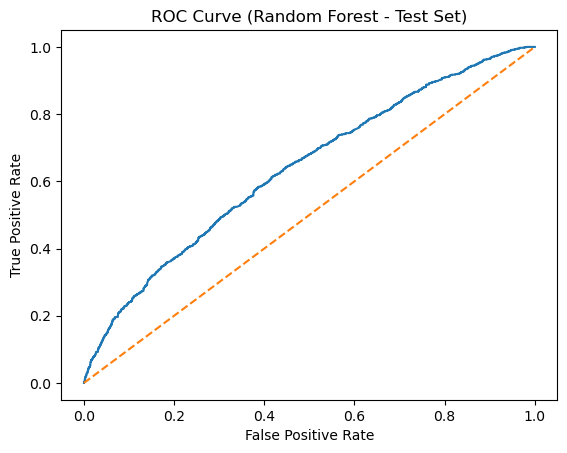

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Random Forest - Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

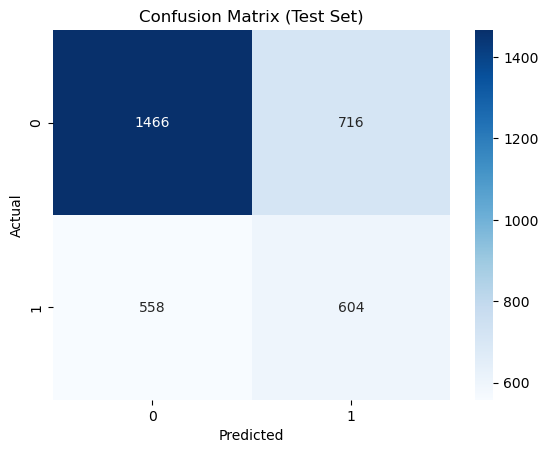

In [15]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
os.makedirs("../artifacts", exist_ok=True)
joblib.dump(pipeline, "../artifacts/final_model_rf.pkl")
print("Model saved.")

Model saved.
